# 02 · Fator casa

Jogar em casa ajuda? Quis responder três coisas:

1. Quanto vale o mando de campo no Brasileirão
2. Se essa vantagem mudou ao longo dos anos
3. O que aconteceu quando os estádios ficaram vazios na pandemia

A pandemia criou uma espécie de experimento natural. O mandante continuou jogando no próprio estádio, no gramado que conhece e sem precisar viajar, enquanto o visitante seguia viajando. A grande diferença era a arquibancada vazia. Se a vantagem caiu nesse período, dá pra atribuir boa parte da queda à falta de público.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from src.dados import carregar_partidas
from src.graficos import (
    AZUL, CINZA, DESTAQUE_FUNDO, SUPERFICIE, TINTA, TINTA_SECUNDARIA, TINTA_SUAVE, VERMELHO,
    aplicar_estilo, eixo_percentual, fonte, salvar, titulo,
)

aplicar_estilo()
partidas = carregar_partidas()

## Quanto vale jogar em casa

In [2]:
partidas["resultado"].value_counts(normalize=True).round(3)

resultado
mandante     0.496
empate       0.264
visitante    0.240
Name: proportion, dtype: float64

In [3]:
print(f"Pontos por jogo do mandante: {partidas['pontos_mandante'].mean():.2f}")
print(f"Pontos por jogo do visitante: {partidas['pontos_visitante'].mean():.2f}")

Pontos por jogo do mandante: 1.75
Pontos por jogo do visitante: 0.98


Nas 22 temporadas, o mandante venceu metade dos jogos (49,6%) e o visitante, só um em cada quatro (24,0%). Em pontos, o mandante fez 1,75 por jogo e o visitante, 0,98.

Para resumir isso num número só, daqui pra frente uso a **vantagem do mandante**: pontos do mandante menos pontos do visitante, na média por jogo. No período todo, ela fica em 0,77.

## A vantagem vem caindo

Calculei os números por temporada em SQL, com o DuckDB consultando direto o DataFrame:

In [4]:
por_temporada = duckdb.sql("""
    SELECT
        temporada,
        COUNT(*) AS jogos,
        AVG(CASE WHEN resultado = 'mandante' THEN 1 ELSE 0 END) AS vitorias_mandante,
        AVG(CASE WHEN resultado = 'empate' THEN 1 ELSE 0 END) AS empates,
        AVG(CASE WHEN resultado = 'visitante' THEN 1 ELSE 0 END) AS vitorias_visitante,
        AVG(pontos_mandante - pontos_visitante) AS vantagem_mandante
    FROM partidas
    GROUP BY temporada
    ORDER BY temporada
""").df()

por_temporada.round(3)

,temporada,jogos,vitorias_mandante,empates,vitorias_visitante,vantagem_mandante
0,2003,552,0.538,0.257,0.205,1.000
1,2004,552,0.522,0.254,0.225,0.891
2,2005,462,0.509,0.221,0.271,0.714
3,2006,380,0.503,0.255,0.242,0.782
4,2007,380,0.505,0.237,0.258,0.742
5,2008,380,0.547,0.253,0.200,1.042
6,2009,380,0.513,0.268,0.218,0.884
7,2010,380,0.471,0.311,0.218,0.758
8,2011,380,0.484,0.276,0.239,0.734
9,2012,380,0.482,0.276,0.242,0.718


In [5]:
tendencia = stats.linregress(por_temporada["temporada"], por_temporada["vitorias_mandante"])

print(f"Variação: {tendencia.slope * 1000:+.1f} pontos percentuais por década")
print(f"p-valor: {tendencia.pvalue:.4f}")

Variação: -2.9 pontos percentuais por década
p-valor: 0.0036


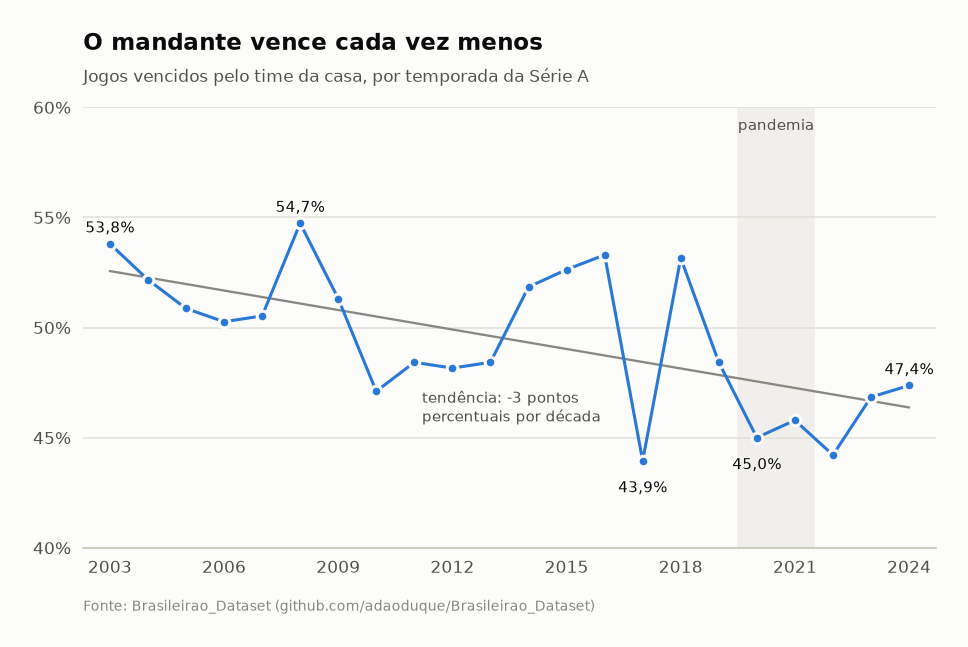

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.2))

anos = por_temporada["temporada"]
vitorias = por_temporada.set_index("temporada")["vitorias_mandante"]

ax.axvspan(2019.5, 2021.5, color=DESTAQUE_FUNDO, zorder=0)
ax.text(2020.5, 0.595, "pandemia", ha="center", va="top", fontsize=10, color=TINTA_SECUNDARIA)

ax.plot(anos, tendencia.intercept + tendencia.slope * anos, color=TINTA_SUAVE, linewidth=1.5)
ax.text(2011.2, 0.472, "tendência: -3 pontos\npercentuais por década", va="top", fontsize=10, color=TINTA_SECUNDARIA)

ax.plot(
    anos, vitorias, color=AZUL, marker="o", markersize=7,
    markeredgecolor=SUPERFICIE, markeredgewidth=2,
)

destaques = {2003: (0, 10), 2008: (0, 10), 2017: (0, -18), 2020: (0, -18), 2024: (0, 10)}
for ano, deslocamento in destaques.items():
    ax.annotate(
        f"{vitorias[ano]:.1%}".replace(".", ","), xy=(ano, vitorias[ano]),
        xytext=deslocamento, textcoords="offset points",
        ha="center", va="center", fontsize=10, color=TINTA,
    )

ax.set_ylim(0.40, 0.60)
ax.set_yticks(np.arange(0.40, 0.61, 0.05))
ax.set_xlim(2002.3, 2024.7)
ax.set_xticks(range(2003, 2025, 3))
eixo_percentual(ax.yaxis)

titulo(ax, "O mandante vence cada vez menos", "Jogos vencidos pelo time da casa, por temporada da Série A")
fonte(ax, deslocamento=-34)
salvar(fig, "fator_casa_temporadas.png")
plt.show()

A vitória do mandante caiu cerca de 3 pontos percentuais por década, e a tendência é estatisticamente significativa (p = 0,004).

A queda não é uma linha reta. Tem temporada bem fora da curva, como 2017 (43,9%) logo antes de 2018 (53,2%). Com 380 jogos por ano, a taxa de vitória do mandante oscila uns 5 pontos para cima ou para baixo só por acaso, então uma temporada isolada não prova nada. Por isso, para avaliar a pandemia, comparei períodos inteiros em vez de anos soltos.

## E sem torcida?

No Brasileirão, os jogos foram de portões fechados durante toda a temporada 2020 (de agosto de 2020 a fevereiro de 2021) e na de 2021 até setembro. O público voltou aos poucos e com capacidade limitada a partir de 2 de outubro de 2021 ([Poder360](https://www.poder360.com.br/brasil/serie-a-do-brasileirao-volta-a-ter-publico-presencial-neste-fim-de-semana/)).

Separei quatro períodos. Como a vantagem já vinha caindo, comparar com a série inteira desde 2003 exageraria a queda. Usei como referência as seis temporadas anteriores à pandemia (2014 a 2019).

In [7]:
periodos = duckdb.sql("""
    SELECT
        CASE
            WHEN temporada BETWEEN 2014 AND 2019 THEN '1. Antes (2014-2019)'
            WHEN data < DATE '2021-10-02' THEN '2. Sem torcida (ago/2020-set/2021)'
            WHEN temporada = 2021 THEN '3. Volta parcial (out-dez/2021)'
            ELSE '4. Depois (2022-2024)'
        END AS periodo,
        resultado,
        pontos_mandante - pontos_visitante AS vantagem
    FROM partidas
    WHERE temporada >= 2014
""").df()


def resumir(grupo):
    n = len(grupo)
    media = grupo["vantagem"].mean()
    margem = stats.t.ppf(0.975, n - 1) * grupo["vantagem"].std() / np.sqrt(n)
    return pd.Series({
        "jogos": n,
        "vitorias_mandante": (grupo["resultado"] == "mandante").mean(),
        "empates": (grupo["resultado"] == "empate").mean(),
        "vitorias_visitante": (grupo["resultado"] == "visitante").mean(),
        "vantagem_mandante": media,
        "ic95_min": media - margem,
        "ic95_max": media + margem,
    })


resumo = periodos.groupby("periodo")[["resultado", "vantagem"]].apply(resumir)
resumo["jogos"] = resumo["jogos"].astype(int)
resumo.round(3)

,jogos,vitorias_mandante,empates,vitorias_visitante,vantagem_mandante,ic95_min,ic95_max
periodo,,,,,,,
1. Antes (2014-2019),2279,0.505,0.258,0.237,0.807,0.706,0.908
2. Sem torcida (ago/2020-set/2021),594,0.424,0.300,0.276,0.444,0.245,0.644
3. Volta parcial (out-dez/2021),166,0.560,0.259,0.181,1.139,0.782,1.495
4. Depois (2022-2024),1140,0.461,0.269,0.269,0.576,0.431,0.722


As colunas `ic95_min` e `ic95_max` são o intervalo de confiança de 95% da vantagem do mandante: a faixa onde o valor verdadeiro provavelmente está, dado o tamanho de cada período.

Para saber se as diferenças entre os períodos são reais ou podem ser acaso, usei o teste t de Welch (que não assume variâncias iguais) sobre a vantagem de cada jogo:

In [8]:
grupos = {nome[3:]: dados["vantagem"] for nome, dados in periodos.groupby("periodo")}

comparacoes = [
    ("Antes (2014-2019)", "Sem torcida (ago/2020-set/2021)"),
    ("Antes (2014-2019)", "Depois (2022-2024)"),
    ("Sem torcida (ago/2020-set/2021)", "Depois (2022-2024)"),
]

for a, b in comparacoes:
    teste = stats.ttest_ind(grupos[a], grupos[b], equal_var=False)
    print(f"{a} x {b}: p-valor = {teste.pvalue:.4f}")

Antes (2014-2019) x Sem torcida (ago/2020-set/2021): p-valor = 0.0015
Antes (2014-2019) x Depois (2022-2024): p-valor = 0.0106
Sem torcida (ago/2020-set/2021) x Depois (2022-2024): p-valor = 0.2940


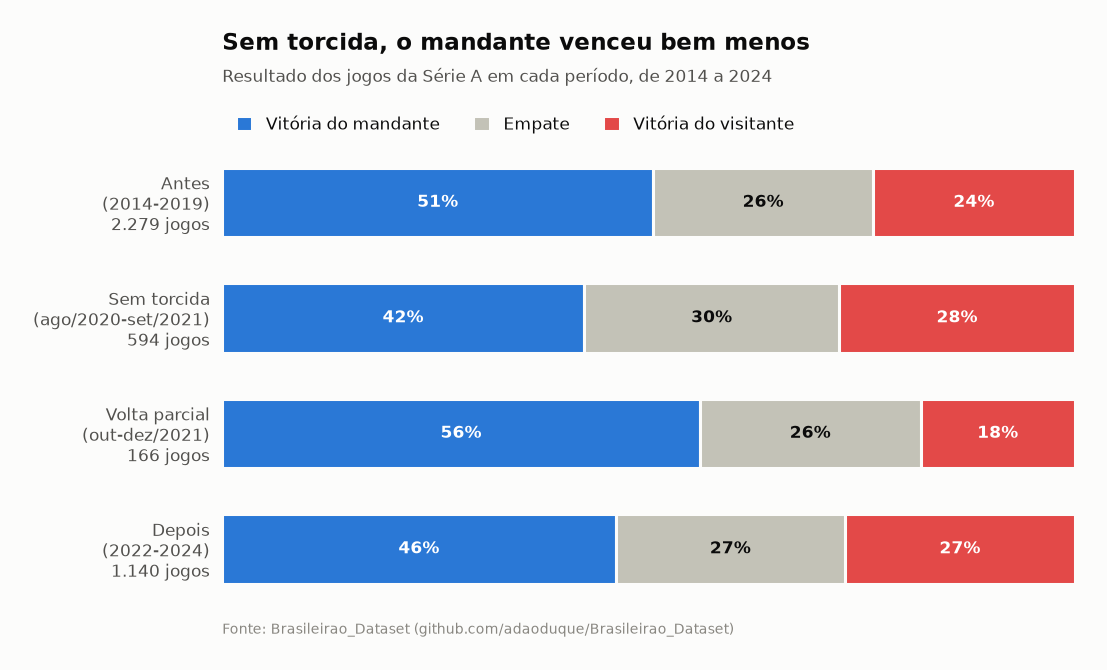

In [9]:
rotulos = []
for nome, jogos in resumo["jogos"].items():
    periodo, intervalo = nome[3:].split(" (")
    rotulos.append(f"{periodo}\n({intervalo}\n{int(jogos):,} jogos".replace(",", "."))

segmentos = [
    ("vitorias_mandante", "Vitória do mandante", AZUL, "white"),
    ("empates", "Empate", CINZA, TINTA),
    ("vitorias_visitante", "Vitória do visitante", VERMELHO, "white"),
]

fig, ax = plt.subplots(figsize=(10, 5.4))
y = np.arange(len(resumo))[::-1]
inicio = np.zeros(len(resumo))

for coluna, nome, cor, cor_texto in segmentos:
    valores = resumo[coluna].to_numpy()
    ax.barh(y, valores, left=inicio, height=0.6, color=cor, edgecolor=SUPERFICIE, linewidth=2, label=nome)
    for posicao, comeco, valor in zip(y, inicio, valores):
        ax.text(
            comeco + valor / 2, posicao, f"{valor:.0%}",
            ha="center", va="center", fontsize=11, fontweight="bold", color=cor_texto,
        )
    inicio += valores

ax.set_yticks(y, rotulos)
ax.set_xlim(0, 1)
ax.xaxis.set_visible(False)
ax.grid(False)
ax.spines["bottom"].set_visible(False)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncol=3, handlelength=1, handleheight=1, borderaxespad=0.4)

titulo(
    ax, "Sem torcida, o mandante venceu bem menos",
    "Resultado dos jogos da Série A em cada período, de 2014 a 2024",
    espaco=26,
)
fonte(ax, deslocamento=-12)
salvar(fig, "fator_casa_pandemia.png")
plt.show()

**Sem torcida**, a vitória do mandante caiu de 50,5% para 42,4%, e a vantagem do mandante caiu quase pela metade: de 0,81 para 0,44 ponto por jogo. A diferença é estatisticamente significativa (p = 0,002).

**Na volta parcial do público**, o mandante venceu 56% dos jogos. São só 166 partidas, todas na reta final do campeonato, então eu não levaria esse número muito a sério. Mas ele aponta na direção esperada.

**Depois da pandemia** vem a parte mais curiosa. De 2022 a 2024, com estádios cheios de novo, a vantagem ficou em 0,58 ponto por jogo: abaixo do que era antes (p = 0,01) e sem diferença estatística em relação ao período sem torcida (p = 0,29).

## Conclusões

- **O mando de campo vale bastante.** Na média das 22 temporadas, o time da casa faz 0,77 ponto a mais por jogo que o visitante.
- **A torcida pesa.** Sem público, essa vantagem caiu quase pela metade.
- **Mas a torcida não explica tudo.** A vantagem já vinha caindo antes da pandemia e não voltou ao nível antigo depois que o público voltou.

Algumas hipóteses que estes dados não conseguem testar: o VAR, usado em todos os jogos desde 2019, pode ter diminuído a influência da pressão da torcida sobre a arbitragem. Também vale lembrar que a temporada 2020 teve um calendário mais apertado que o normal, o que pode ter pesado nos resultados do período sem público.